# GT Keywords Analysis for DRANK Scale

Collect, stem, and analyze ground truth keywords to determine optimal DRANK scale parameters.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.stem.snowball import SnowballStemmer
from nltk.tokenize import word_tokenize
from nltk.tag import pos_tag
import urllib.request
from bs4 import BeautifulSoup
import json
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Download required NLTK data
for package in ['punkt', 'averaged_perceptron_tagger', 'universal_tagset']:
    try:
        nltk.data.find(f'tokenizers/{package}')
    except LookupError:
        nltk.download(package)

# Set style for better visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
print("✓ Libraries imported successfully")

✓ Libraries imported successfully


[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /home/muditha/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package universal_tagset to
[nltk_data]     /home/muditha/nltk_data...
[nltk_data]   Package universal_tagset is already up-to-date!


In [2]:
def fetch_gt_keywords_from_online(dataset_name='ruoka', num_samples=100):
    """Fetch GT keywords from online UEF dataset"""
    all_keywords = []
    
    base_url = f"https://cs.uef.fi/~himat/WebRank/dataset_12/dataset_12/{dataset_name}"
    
    for i in range(num_samples):
        try:
            gt_url = f"{base_url}/{i}/GT.txt"
            with urllib.request.urlopen(gt_url, timeout=5) as response:
                gt_text = response.read().decode("utf-8-sig").strip()
                keywords = gt_text.lower().split()
                all_keywords.extend(keywords)
        except Exception as e:
            pass
    
    return list(set(all_keywords))  # Remove duplicates

# Collect keywords from ruoka dataset only
print("Collecting GT keywords from online sources...")
datasets = ['ruoka']
all_gt_keywords = []

for dataset in datasets:
    keywords = fetch_gt_keywords_from_online(dataset, num_samples=100)
    all_gt_keywords.extend(keywords)
    print(f"  {dataset}: {len(keywords)} unique keywords")

# Remove duplicates and create list
all_gt_keywords = list(set(all_gt_keywords))
print(f"\n✓ Total unique GT keywords collected: {len(all_gt_keywords)}")
print(f"Sample keywords: {all_gt_keywords[:10]}")

  ruoka: 346 unique keywords

✓ Total unique GT keywords collected: 346
Sample keywords: ['riisipuuro', 'jäätelökone', 'vanilja', 'sinihomejuusto', 'masala', 'korvasieni', 'ranskalainen', 'inkivääri', 'sobanuudeli', 'kinkku']


In [3]:
# Initialize Stemmer
try:
    stemmer = SnowballStemmer('finnish')
except:
    stemmer = SnowballStemmer('english')

# Apply stemming to all keywords
stemmed_keywords = [stemmer.stem(keyword) for keyword in all_gt_keywords]

# Create DataFrame with original and stemmed forms
keywords_df = pd.DataFrame({
    'original': all_gt_keywords,
    'stemmed': stemmed_keywords
})

# Remove duplicates in stemmed form (keeping first occurrence)
keywords_df = keywords_df.drop_duplicates(subset=['stemmed'], keep='first').reset_index(drop=True)

print(f"✓ Keywords stemmed")
print(f"  Unique stemmed forms: {len(keywords_df)}")
print(f"\nSample (Original → Stemmed):")
print(keywords_df.head(10).to_string(index=False))


✓ Keywords stemmed
  Unique stemmed forms: 332

Sample (Original → Stemmed):
      original        stemmed
    riisipuuro     riisipuuro
   jäätelökone     jäätelökon
       vanilja         vanilj
sinihomejuusto sinihomejuusto
        masala          masal
    korvasieni       korvasie
  ranskalainen     ranskalain
     inkivääri       inkiväär
   sobanuudeli     sobanuudel
        kinkku          kinku


In [4]:
# Calculate keyword length statistics
keywords_df['length'] = keywords_df['stemmed'].apply(len)

# Calculate statistics
length_stats = {
    'mean': keywords_df['length'].mean(),
    'median': keywords_df['length'].median(),
    'min': keywords_df['length'].min(),
    'max': keywords_df['length'].max(),
    'std': keywords_df['length'].std()
}

print("✓ Keyword Length Analysis")
print(f"  Mean length: {length_stats['mean']:.2f} characters")
print(f"  Median length: {length_stats['median']:.0f} characters")
print(f"  Min length: {length_stats['min']} characters")
print(f"  Max length: {length_stats['max']} characters")
print(f"  Std Dev: {length_stats['std']:.2f}")

# Length categories
keywords_df['length_category'] = pd.cut(keywords_df['length'], 
                                         bins=[0, 3, 6, 9, 20], 
                                         labels=['Very Short (1-3)', 'Short (4-6)', 'Medium (7-9)', 'Long (10+)'])

length_category_counts = keywords_df['length_category'].value_counts().sort_index()
print(f"\nLength Categories:")
for cat, count in length_category_counts.items():
    print(f"  {cat}: {count} keywords")


✓ Keyword Length Analysis
  Mean length: 7.59 characters
  Median length: 7 characters
  Min length: 2 characters
  Max length: 16 characters
  Std Dev: 2.98

Length Categories:
  Very Short (1-3): 15 keywords
  Short (4-6): 125 keywords
  Medium (7-9): 109 keywords
  Long (10+): 83 keywords


In [5]:
# Function to get POS tag
def get_pos_tag(word):
    """Get POS tag for a word using NLTK"""
    try:
        tokens = word_tokenize(word)
        pos_tags = pos_tag(tokens, tagset='universal')
        return pos_tags[0][1] if pos_tags else 'UNK'
    except:
        return 'UNK'

# Map POS tags to readable labels
pos_mapping = {
    'NOUN': 'Noun',
    'VERB': 'Verb',
    'ADJ': 'Adjective',
    'ADV': 'Adverb',
    'PRON': 'Pronoun',
    'ADP': 'Adposition',
    'CCONJ': 'Conjunction',
    'DET': 'Determiner',
    'NUM': 'Number',
    'X': 'Other',
    'UNK': 'Unknown'
}

# Apply POS tagging
keywords_df['pos_tag_raw'] = keywords_df['stemmed'].apply(get_pos_tag)
keywords_df['pos_tag'] = keywords_df['pos_tag_raw'].apply(lambda x: pos_mapping.get(x, 'Other'))

# Count POS categories
pos_counts = keywords_df['pos_tag'].value_counts()

print("✓ Parts of Speech Analysis")
print(f"\nPOS Distribution:")
for pos, count in pos_counts.items():
    percentage = (count / len(keywords_df)) * 100
    print(f"  {pos}: {count} ({percentage:.1f}%)")


✓ Parts of Speech Analysis

POS Distribution:
  Noun: 329 (99.1%)
  Verb: 2 (0.6%)
  Determiner: 1 (0.3%)


In [6]:
# Create analysis summary for DRANK scale decision
analysis_summary = {
    'Total Keywords': len(keywords_df),
    'Avg Length': f"{length_stats['mean']:.1f}",
    'Most Common Length': f"{keywords_df['length'].mode()[0]}",
    'Length Range': f"{length_stats['min']}-{length_stats['max']}",
    'Most Common POS': pos_counts.index[0],
    'POS Diversity': len(pos_counts)
}

# Create length distribution for DRANK scaling
length_dist = keywords_df['length'].value_counts().sort_index()

# Create POS distribution summary
pos_dist = keywords_df['pos_tag'].value_counts()

print("✓ DRANK Scale Decision Data Prepared")
print("\nSummary Metrics:")
for key, value in analysis_summary.items():
    print(f"  {key}: {value}")

# Save consolidated data
keywords_df_output = keywords_df[['original', 'stemmed', 'length', 'length_category', 'pos_tag']].copy()
print(f"\n✓ Analysis complete. DataFrame has {len(keywords_df_output)} keywords")


✓ DRANK Scale Decision Data Prepared

Summary Metrics:
  Total Keywords: 332
  Avg Length: 7.6
  Most Common Length: 5
  Length Range: 2-16
  Most Common POS: Noun
  POS Diversity: 3

✓ Analysis complete. DataFrame has 332 keywords


✓ Visualization saved as 'gt_keywords_drank_analysis.png'


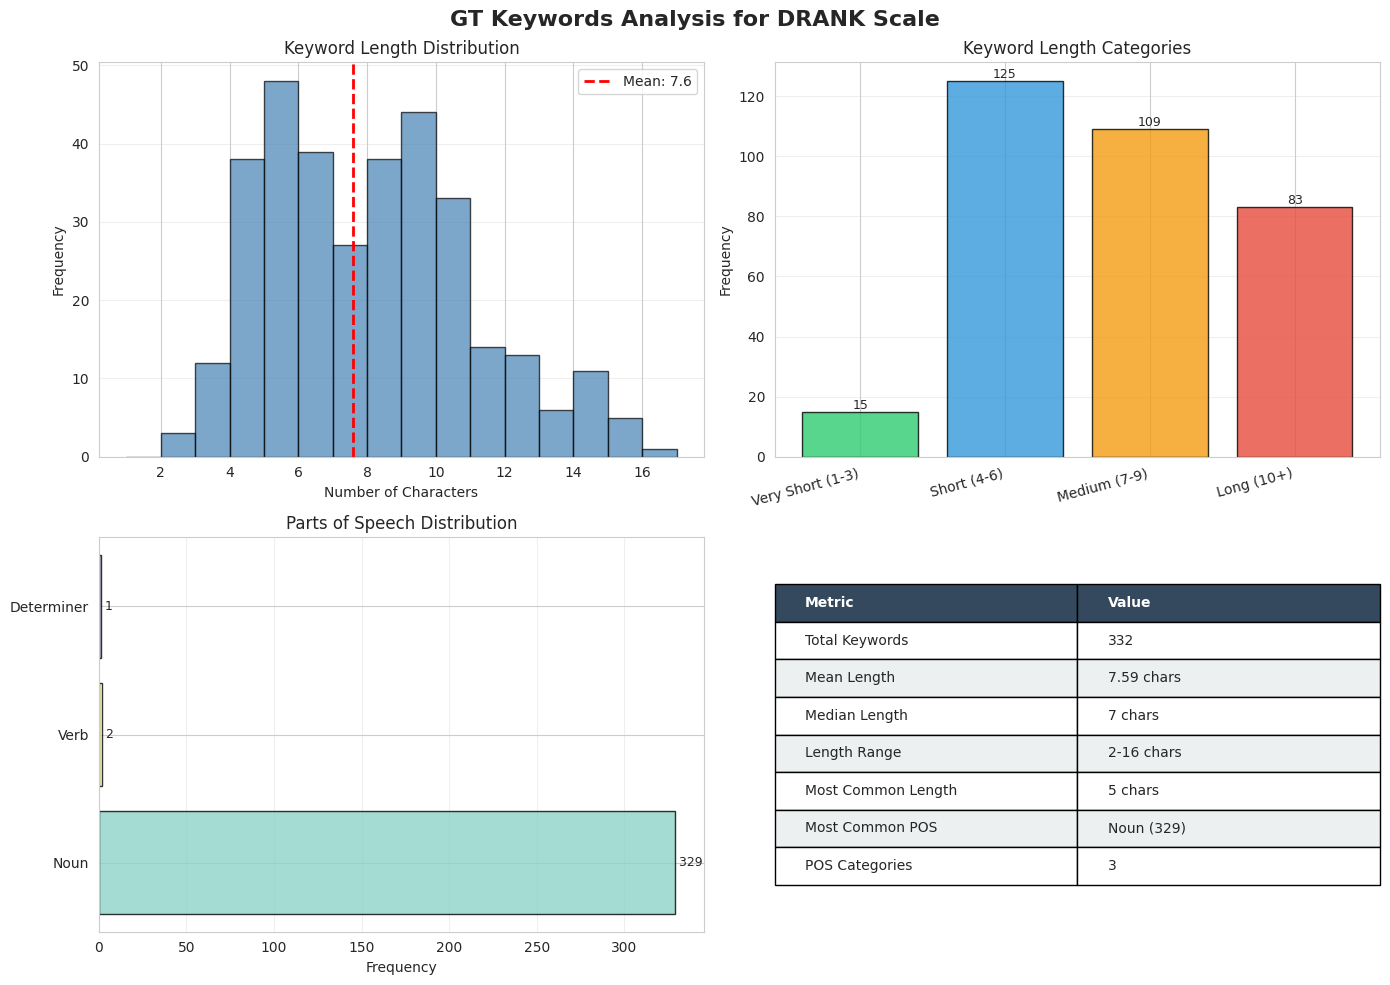

In [7]:
# Create comprehensive visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('GT Keywords Analysis for DRANK Scale', fontsize=16, fontweight='bold')

# 1. Keyword Length Distribution (Histogram)
ax1 = axes[0, 0]
ax1.hist(keywords_df['length'], bins=range(1, int(keywords_df['length'].max()) + 2), 
         color='steelblue', edgecolor='black', alpha=0.7)
ax1.set_xlabel('Number of Characters')
ax1.set_ylabel('Frequency')
ax1.set_title('Keyword Length Distribution')
ax1.grid(axis='y', alpha=0.3)
ax1.axvline(keywords_df['length'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {keywords_df["length"].mean():.1f}')
ax1.legend()

# 2. Length Categories (Bar Chart)
ax2 = axes[0, 1]
length_cat_counts = keywords_df['length_category'].value_counts().sort_index()
colors = ['#2ecc71', '#3498db', '#f39c12', '#e74c3c']
bars = ax2.bar(range(len(length_cat_counts)), length_cat_counts.values, color=colors, edgecolor='black', alpha=0.8)
ax2.set_xticks(range(len(length_cat_counts)))
ax2.set_xticklabels(length_cat_counts.index, rotation=15, ha='right')
ax2.set_ylabel('Frequency')
ax2.set_title('Keyword Length Categories')
ax2.grid(axis='y', alpha=0.3)
# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}', ha='center', va='bottom', fontsize=9)

# 3. Parts of Speech Distribution (Bar Chart)
ax3 = axes[1, 0]
pos_counts_top = keywords_df['pos_tag'].value_counts().head(8)
colors_pos = plt.cm.Set3(range(len(pos_counts_top)))
bars = ax3.barh(range(len(pos_counts_top)), pos_counts_top.values, color=colors_pos, edgecolor='black', alpha=0.8)
ax3.set_yticks(range(len(pos_counts_top)))
ax3.set_yticklabels(pos_counts_top.index)
ax3.set_xlabel('Frequency')
ax3.set_title('Parts of Speech Distribution')
ax3.grid(axis='x', alpha=0.3)
# Add value labels
for i, bar in enumerate(bars):
    width = bar.get_width()
    ax3.text(width, bar.get_y() + bar.get_height()/2.,
            f' {int(width)}', ha='left', va='center', fontsize=9)

# 4. Summary Statistics Table
ax4 = axes[1, 1]
ax4.axis('tight')
ax4.axis('off')

summary_data = [
    ['Metric', 'Value'],
    ['Total Keywords', f"{len(keywords_df)}"],
    ['Mean Length', f"{length_stats['mean']:.2f} chars"],
    ['Median Length', f"{length_stats['median']:.0f} chars"],
    ['Length Range', f"{length_stats['min']}-{length_stats['max']} chars"],
    ['Most Common Length', f"{keywords_df['length'].mode()[0]} chars"],
    ['Most Common POS', f"{pos_counts.index[0]} ({pos_counts.values[0]})"],
    ['POS Categories', f"{len(pos_counts)}"],
]

table = ax4.table(cellText=summary_data, cellLoc='left', loc='center',
                  colWidths=[0.5, 0.5])
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2)

# Style header row
for i in range(2):
    table[(0, i)].set_facecolor('#34495e')
    table[(0, i)].set_text_props(weight='bold', color='white')

# Alternate row colors
for i in range(1, len(summary_data)):
    for j in range(2):
        if i % 2 == 0:
            table[(i, j)].set_facecolor('#ecf0f1')
        else:
            table[(i, j)].set_facecolor('#ffffff')

plt.tight_layout()
plt.savefig('gt_keywords_drank_analysis.png', dpi=150, bbox_inches='tight')
print("✓ Visualization saved as 'gt_keywords_drank_analysis.png'")
plt.show()


In [8]:
# DRANK Scale Recommendations
print("=" * 60)
print("DRANK SCALE CONFIGURATION RECOMMENDATIONS")
print("=" * 60)

# Length-based recommendation
avg_length = keywords_df['length'].mean()
if avg_length < 4:
    length_rec = "SHORT - Scale small, minimal text processing needed"
elif avg_length < 7:
    length_rec = "MEDIUM - Standard scale, moderate processing"
else:
    length_rec = "LONG - Scale large, robust text processing required"

print(f"\n1. LENGTH-BASED SCALE:")
print(f"   Average keyword length: {avg_length:.1f} characters")
print(f"   Recommendation: {length_rec}")

# POS-based recommendation
noun_ratio = (keywords_df['pos_tag'] == 'Noun').sum() / len(keywords_df) * 100
verb_ratio = (keywords_df['pos_tag'] == 'Verb').sum() / len(keywords_df) * 100

print(f"\n2. POS-BASED SCALE:")
print(f"   Noun-dominated: {noun_ratio:.1f}%")
print(f"   Verb-based: {verb_ratio:.1f}%")
if noun_ratio > 50:
    print(f"   Recommendation: NOUN-FOCUSED extraction algorithm")
else:
    print(f"   Recommendation: MIXED POS handling required")

# Complexity recommendation
short_pct = (keywords_df['length'] <= 3).sum() / len(keywords_df) * 100
long_pct = (keywords_df['length'] >= 10).sum() / len(keywords_df) * 100

print(f"\n3. COMPLEXITY SCALE:")
print(f"   Short keywords (≤3 chars): {short_pct:.1f}%")
print(f"   Long keywords (≥10 chars): {long_pct:.1f}%")
if short_pct > 50:
    print(f"   Recommendation: SIMPLE DRANK scale, short keyword handling")
elif long_pct > 30:
    print(f"   Recommendation: COMPLEX DRANK scale, compound word handling")
else:
    print(f"   Recommendation: BALANCED DRANK scale")

# Export results
export_df = keywords_df[['original', 'stemmed', 'length', 'pos_tag']].copy()
export_df.to_csv('gt_keywords_analysis.csv', index=False)
print(f"\n✓ Analysis exported to 'gt_keywords_analysis.csv'")
print("=" * 60)


DRANK SCALE CONFIGURATION RECOMMENDATIONS

1. LENGTH-BASED SCALE:
   Average keyword length: 7.6 characters
   Recommendation: LONG - Scale large, robust text processing required

2. POS-BASED SCALE:
   Noun-dominated: 99.1%
   Verb-based: 0.6%
   Recommendation: NOUN-FOCUSED extraction algorithm

3. COMPLEXITY SCALE:
   Short keywords (≤3 chars): 4.5%
   Long keywords (≥10 chars): 25.0%
   Recommendation: BALANCED DRANK scale

✓ Analysis exported to 'gt_keywords_analysis.csv'


## 8. Map GT Keywords in HTML Tags (Ruoka)

Top tag match rates:
   tag  total_filtered_words  gt_matches  pages    score
    h1                   227         143     86 0.629956
     b                     2           1      1 0.500000
   div                    55          26     21 0.472727
strong                   204          75     22 0.367647
    h3                  2062         724     71 0.351115
     a                  9446        3256    100 0.344696
    em                     6           2      1 0.333333
    h4                     6           2      2 0.333333
     p                 12708        2335     98 0.183743
     u                    11           2      1 0.181818


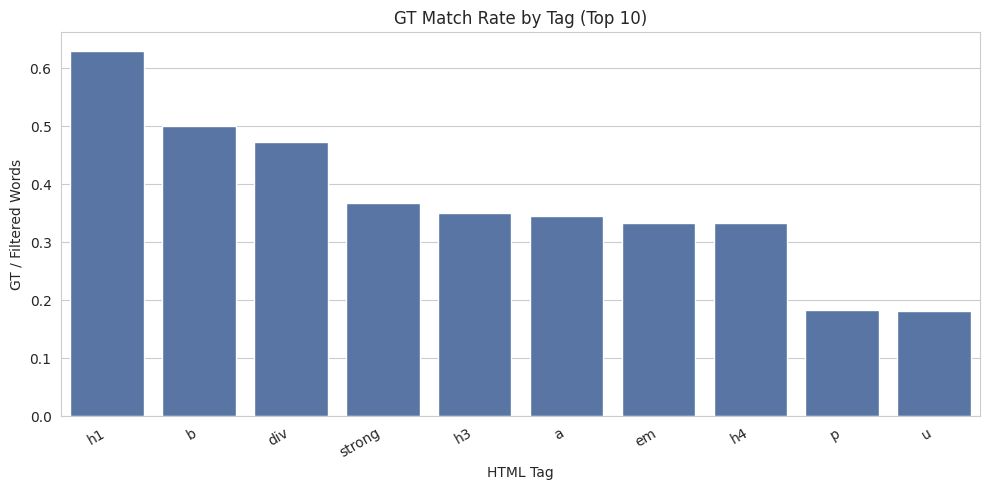


Sample GT locations (first 20):
 page_index tag     gt_stem        positions
          0   a        test              [9]
          0   a        muka     [10, 36, 43]
          0   a        maku [11, 23, 37, 44]
          0   a        juhl             [16]
          0   a       joulu             [20]
          0   a       juoma             [21]
          0   a      maailm   [24, 113, 115]
          0   a      leivon             [34]
          0   a      berber             [39]
          0   a        kana             [40]
          0   a     kikhern             [41]
          0   a      maroko             [42]
          0   a    pataruoa             [46]
          0   a         tag             [47]
          0   a         taj             [48]
          0   a        peru             [59]
          0   a kotijäätelö             [65]
          0   a        nute             [68]
          0   a          ja             [78]
          0   a          an             [94]

Saved: gt_tag_summary

In [9]:
import re

def read_url_content(url):
    try:
        with urllib.request.urlopen(url, timeout=8) as response:
            return response.read()
    except Exception:
        return None

def is_visible_text(element):
    if element.parent.name in ["style", "script", "head", "title", "meta", "[document]"]:
        return False
    if element.__class__.__name__ == "Comment":
        return False
    return True

def get_stop_words():
    try:
        return set(stopwords.words('finnish'))
    except Exception:
        try:
            return set(stopwords.words('english'))
        except Exception:
            return set()

stop_words = get_stop_words()

# Extract tokens by HTML tag

def extract_tag_tokens(html_content):
    soup = BeautifulSoup(html_content, "lxml")
    tag_tokens = {}

    for node in soup.find_all(string=True):
        if not is_visible_text(node):
            continue
        text = node.strip()
        if not text:
            continue
        words = re.findall(r"[A-Za-zÅÄÖåäö]+", text.lower())
        if not words:
            continue
        tag = node.parent.name
        tag_tokens.setdefault(tag, []).extend(words)

    return tag_tokens

# Analyze GT keyword locations in tags

def analyze_page_tags(page_index, gt_stems, length_min, length_max):
    base_url = "https://cs.uef.fi/~himat/WebRank/dataset_12/dataset_12/ruoka"
    html_content = read_url_content(f"{base_url}/{page_index}/")
    if not html_content:
        return None, None

    tag_tokens = extract_tag_tokens(html_content)
    results = []
    locations = []

    for tag, tokens in tag_tokens.items():
        if not tokens:
            continue
        try:
            tagged = pos_tag(tokens, tagset='universal')
        except Exception:
            tagged = [(t, 'UNK') for t in tokens]

        filtered = []
        for idx, (tok, pos_tagged) in enumerate(tagged):
            if tok in stop_words:
                continue
            if len(tok) < length_min or len(tok) > length_max:
                continue
            if pos_tagged != 'NOUN':
                continue
            filtered.append((idx, tok))

        total_filtered = len(filtered)
        if total_filtered == 0:
            continue

        gt_count = 0
        tag_location_map = {}
        for idx, tok in filtered:
            stem = stemmer.stem(tok)
            if stem in gt_stems:
                gt_count += 1
                tag_location_map.setdefault(stem, []).append(idx)

        if gt_count == 0:
            continue

        score = gt_count / total_filtered
        results.append({
            "page_index": page_index,
            "tag": tag,
            "total_filtered_words": total_filtered,
            "gt_matches": gt_count,
            "score": score,
            "unique_gt_matched": len(tag_location_map)
        })

        for stem, positions in tag_location_map.items():
            locations.append({
                "page_index": page_index,
                "tag": tag,
                "gt_stem": stem,
                "positions": positions
            })

    results_df = pd.DataFrame(results).sort_values("score", ascending=False)
    locations_df = pd.DataFrame(locations)
    return results_df, locations_df

# Run analysis for ruoka pages

gt_stems = set(keywords_df['stemmed'].tolist())
length_min = int(length_stats['min'])
length_max = int(length_stats['max'])

pages_to_scan = 100
all_tag_results = []
all_locations = []

for page_index in range(pages_to_scan):
    page_results, page_locations = analyze_page_tags(page_index, gt_stems, length_min, length_max)
    if page_results is not None and not page_results.empty:
        all_tag_results.append(page_results)
    if page_locations is not None and not page_locations.empty:
        all_locations.append(page_locations)

if not all_tag_results:
    print("No GT keyword matches found.")
else:
    tag_results_df = pd.concat(all_tag_results, ignore_index=True)
    location_results_df = pd.concat(all_locations, ignore_index=True) if all_locations else pd.DataFrame(
        columns=["page_index", "tag", "gt_stem", "positions"]
    )

    tag_summary = tag_results_df.groupby("tag", as_index=False).agg(
        total_filtered_words=("total_filtered_words", "sum"),
        gt_matches=("gt_matches", "sum"),
        pages=("page_index", "nunique")
    )
    tag_summary["score"] = tag_summary["gt_matches"] / tag_summary["total_filtered_words"]
    tag_summary = tag_summary.sort_values("score", ascending=False)

    print("Top tag match rates:")
    print(tag_summary.head(10).to_string(index=False))

    plt.figure(figsize=(10, 5))
    plot_df = tag_summary.head(10)
    sns.barplot(data=plot_df, x="tag", y="score", color="#4c72b0")
    plt.title("GT Match Rate by Tag (Top 10)")
    plt.xlabel("HTML Tag")
    plt.ylabel("GT / Filtered Words")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.savefig("gt_tag_match_rates.png", dpi=150, bbox_inches="tight")
    plt.show()

    print("\nSample GT locations (first 20):")
    print(location_results_df.head(20).to_string(index=False))

    tag_summary.to_csv("gt_tag_summary.csv", index=False)
    location_results_df.to_csv("gt_tag_locations.csv", index=False)
    print("\nSaved: gt_tag_summary.csv, gt_tag_locations.csv, gt_tag_match_rates.png")

## 9. Analyze GT Keyword Multi-Tag Coverage

**Goal**: Determine if GT keywords tend to appear in multiple HTML tags on the same page, which could be used as a filtering criterion for keyword extraction.

In [10]:
def analyze_gt_multi_tag_coverage(page_index):
    """
    For a specific page, find where each GT keyword appears across different HTML tags.
    Returns: dict mapping each GT keyword to the list of tags it appears in
    """
    base_url = "https://cs.uef.fi/~himat/WebRank/dataset_12/dataset_12/ruoka"
    
    # Get GT keywords for this page
    gt_url = f"{base_url}/{page_index}/GT.txt"
    gt_content = read_url_content(gt_url)
    if not gt_content:
        return None, None
    
    gt_text = gt_content.decode("utf-8-sig").strip().lower()
    gt_keywords = gt_text.split()
    gt_stems = {stemmer.stem(kw): kw for kw in gt_keywords}
    
    # Get HTML content
    html_content = read_url_content(f"{base_url}/{page_index}/")
    if not html_content:
        return None, None
    
    # Extract all tokens by tag
    soup = BeautifulSoup(html_content, "lxml")
    gt_tag_map = {}  # Maps GT stem -> list of tags it appears in
    
    for node in soup.find_all(string=True):
        if not is_visible_text(node):
            continue
        
        text = node.strip()
        if not text:
            continue
        
        words = re.findall(r"[A-Za-zÅÄÖåäö]+", text.lower())
        tag = node.parent.name
        
        for word in words:
            stem = stemmer.stem(word)
            if stem in gt_stems:
                if stem not in gt_tag_map:
                    gt_tag_map[stem] = set()
                gt_tag_map[stem].add(tag)
    
    # Convert sets to lists and add original keyword
    result = {}
    for stem, tags in gt_tag_map.items():
        result[stem] = {
            'original': gt_stems[stem],
            'tags': sorted(list(tags)),
            'tag_count': len(tags)
        }
    
    return result, len(gt_stems)

# Analyze multi-tag coverage across all pages
print("Analyzing GT keyword multi-tag coverage...")
print("=" * 70)

multi_tag_data = []
page_coverage_data = []

for page_idx in range(pages_to_scan):
    gt_coverage, total_gt = analyze_gt_multi_tag_coverage(page_idx)
    
    if gt_coverage is None:
        continue
    
    found_gt = len(gt_coverage)
    coverage_rate = found_gt / total_gt if total_gt > 0 else 0
    
    # Per-page statistics
    tag_counts = [info['tag_count'] for info in gt_coverage.values()]
    avg_tags = np.mean(tag_counts) if tag_counts else 0
    multi_tag_count = sum(1 for c in tag_counts if c > 1)
    multi_tag_pct = (multi_tag_count / found_gt * 100) if found_gt > 0 else 0
    
    page_coverage_data.append({
        'page_index': page_idx,
        'total_gt': total_gt,
        'found_gt': found_gt,
        'coverage_rate': coverage_rate,
        'avg_tags_per_gt': avg_tags,
        'multi_tag_gt_count': multi_tag_count,
        'multi_tag_pct': multi_tag_pct
    })
    
    # Individual keyword data
    for stem, info in gt_coverage.items():
        multi_tag_data.append({
            'page_index': page_idx,
            'gt_keyword': info['original'],
            'stem': stem,
            'tag_count': info['tag_count'],
            'tags': ', '.join(info['tags']),
            'in_multiple_tags': info['tag_count'] > 1
        })

multi_tag_df = pd.DataFrame(multi_tag_data)
page_coverage_df = pd.DataFrame(page_coverage_data)

print(f"✓ Analysis complete")
print(f"Total GT keywords analyzed: {len(multi_tag_df)}")
print(f"Pages with GT keywords: {len(page_coverage_df)}")

Analyzing GT keyword multi-tag coverage...
✓ Analysis complete
Total GT keywords analyzed: 716
Pages with GT keywords: 100


In [11]:
# Overall Statistics
print("\n" + "=" * 70)
print("GT KEYWORD MULTI-TAG COVERAGE ANALYSIS")
print("=" * 70)

# How many tags do GT keywords typically appear in?
tag_count_dist = multi_tag_df['tag_count'].value_counts().sort_index()
print(f"\n📊 Tag Count Distribution:")
for count, freq in tag_count_dist.items():
    percentage = (freq / len(multi_tag_df)) * 100
    print(f"   {count} tag(s): {freq} keywords ({percentage:.1f}%)")

# Multi-tag statistics
multi_tag_keywords = multi_tag_df[multi_tag_df['in_multiple_tags']]
multi_tag_percentage = (len(multi_tag_keywords) / len(multi_tag_df)) * 100

print(f"\n🎯 Key Findings:")
print(f"   GT keywords in multiple tags: {len(multi_tag_keywords)}/{len(multi_tag_df)} ({multi_tag_percentage:.1f}%)")
print(f"   GT keywords in single tag: {len(multi_tag_df) - len(multi_tag_keywords)} ({100-multi_tag_percentage:.1f}%)")
print(f"   Average tags per GT keyword: {multi_tag_df['tag_count'].mean():.2f}")
print(f"   Max tags for a GT keyword: {multi_tag_df['tag_count'].max()}")

# Page-level statistics
print(f"\n📄 Page-Level Coverage:")
print(f"   Avg GT keywords found per page: {page_coverage_df['found_gt'].mean():.1f}")
print(f"   Avg coverage rate: {page_coverage_df['coverage_rate'].mean()*100:.1f}%")
print(f"   Avg multi-tag GT per page: {page_coverage_df['multi_tag_gt_count'].mean():.1f}")
print(f"   Avg multi-tag percentage per page: {page_coverage_df['multi_tag_pct'].mean():.1f}%")

# Which tags are most common for GT keywords?
all_tags = []
for tags_str in multi_tag_df['tags']:
    all_tags.extend(tags_str.split(', '))

tag_frequency = Counter(all_tags)
print(f"\n🏷️ Most Common Tags for GT Keywords (Top 15):")
for tag, count in tag_frequency.most_common(15):
    percentage = (count / len(multi_tag_df)) * 100
    print(f"   {tag}: {count} occurrences ({percentage:.1f}% of GT keywords)")

print("=" * 70)


GT KEYWORD MULTI-TAG COVERAGE ANALYSIS

📊 Tag Count Distribution:
   1 tag(s): 322 keywords (45.0%)
   2 tag(s): 179 keywords (25.0%)
   3 tag(s): 113 keywords (15.8%)
   4 tag(s): 62 keywords (8.7%)
   5 tag(s): 31 keywords (4.3%)
   6 tag(s): 8 keywords (1.1%)
   7 tag(s): 1 keywords (0.1%)

🎯 Key Findings:
   GT keywords in multiple tags: 394/716 (55.0%)
   GT keywords in single tag: 322 (45.0%)
   Average tags per GT keyword: 2.06
   Max tags for a GT keyword: 7

📄 Page-Level Coverage:
   Avg GT keywords found per page: 7.2
   Avg coverage rate: 99.0%
   Avg multi-tag GT per page: 3.9
   Avg multi-tag percentage per page: 53.9%

🏷️ Most Common Tags for GT Keywords (Top 15):
   a: 713 occurrences (99.6% of GT keywords)
   p: 292 occurrences (40.8% of GT keywords)
   span: 181 occurrences (25.3% of GT keywords)
   h1: 122 occurrences (17.0% of GT keywords)
   li: 69 occurrences (9.6% of GT keywords)
   strong: 45 occurrences (6.3% of GT keywords)
   h3: 37 occurrences (5.2% of GT ke


✓ Visualization saved as 'gt_multi_tag_analysis.png'


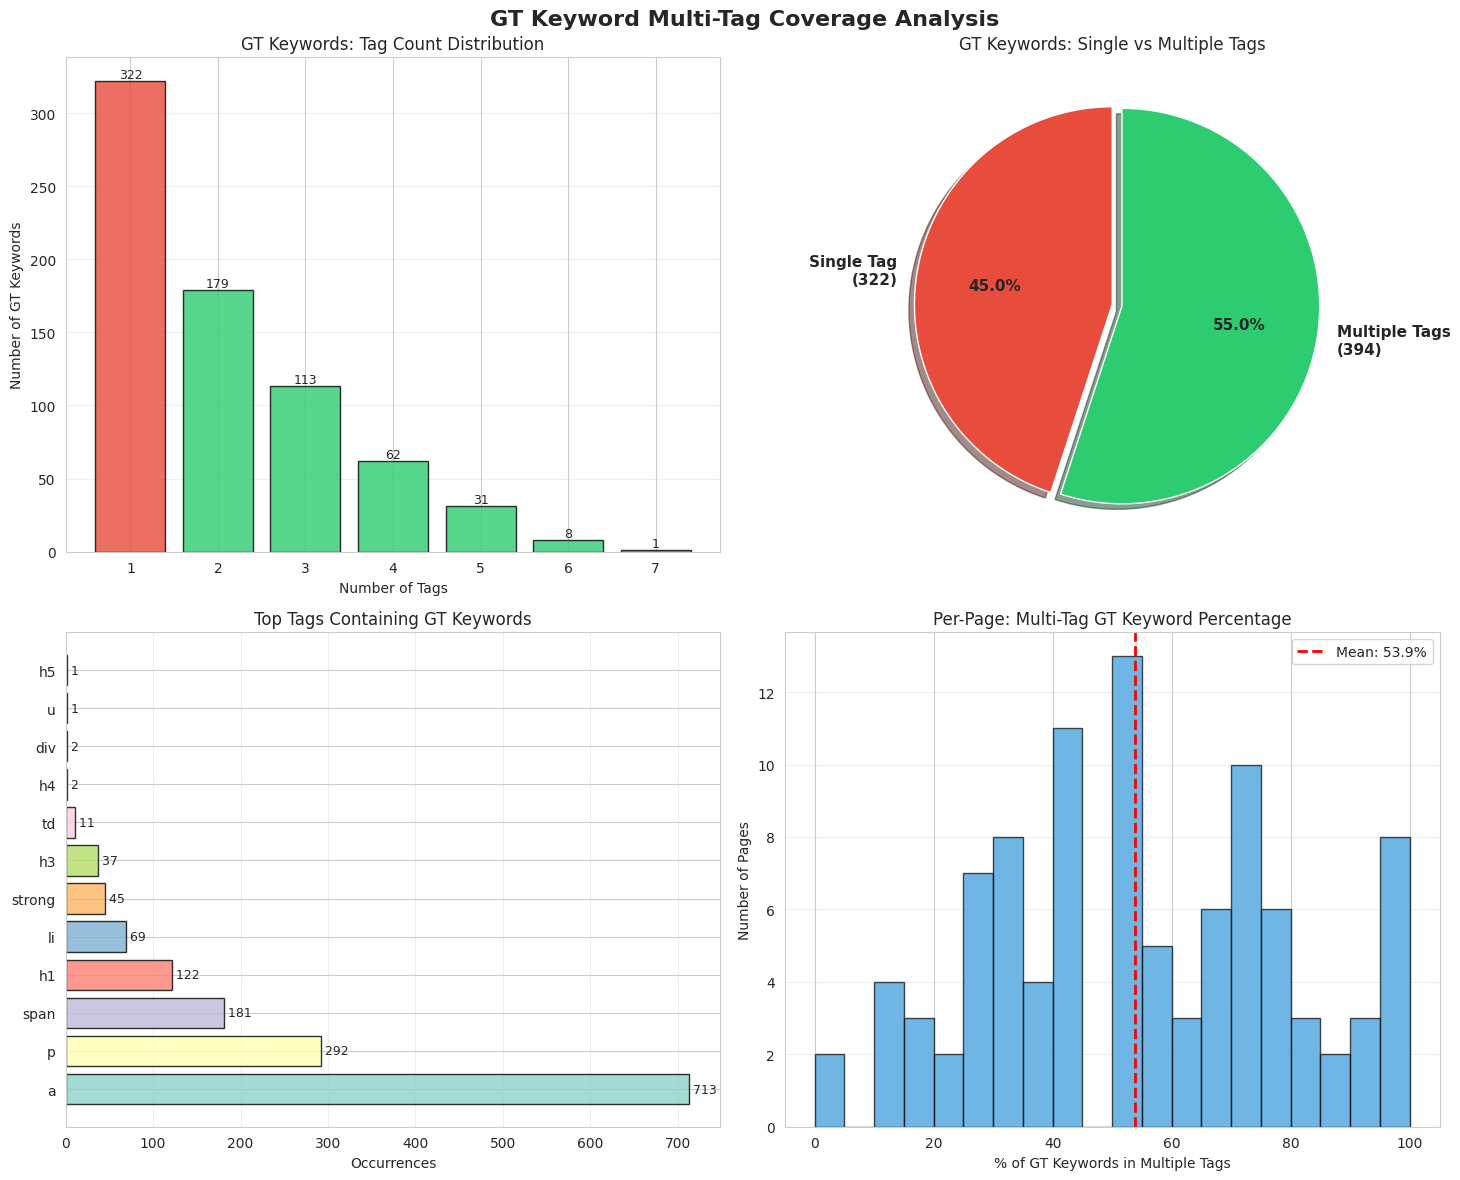

In [12]:
# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('GT Keyword Multi-Tag Coverage Analysis', fontsize=16, fontweight='bold')

# 1. Tag Count Distribution
ax1 = axes[0, 0]
tag_counts = multi_tag_df['tag_count'].value_counts().sort_index()
colors = ['#e74c3c' if c == 1 else '#2ecc71' for c in tag_counts.index]
bars = ax1.bar(tag_counts.index, tag_counts.values, color=colors, edgecolor='black', alpha=0.8)
ax1.set_xlabel('Number of Tags')
ax1.set_ylabel('Number of GT Keywords')
ax1.set_title('GT Keywords: Tag Count Distribution')
ax1.grid(axis='y', alpha=0.3)
ax1.set_xticks(range(1, int(tag_counts.index.max()) + 1))
# Add value labels
for bar in bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}', ha='center', va='bottom', fontsize=9)

# 2. Single vs Multi-Tag Pie Chart
ax2 = axes[0, 1]
single_tag = len(multi_tag_df[multi_tag_df['tag_count'] == 1])
multiple_tags = len(multi_tag_df[multi_tag_df['tag_count'] > 1])
sizes = [single_tag, multiple_tags]
labels = [f'Single Tag\n({single_tag})', f'Multiple Tags\n({multiple_tags})']
colors_pie = ['#e74c3c', '#2ecc71']
explode = (0, 0.05)
ax2.pie(sizes, explode=explode, labels=labels, colors=colors_pie, autopct='%1.1f%%',
        shadow=True, startangle=90, textprops={'fontsize': 11, 'fontweight': 'bold'})
ax2.set_title('GT Keywords: Single vs Multiple Tags')

# 3. Top Tags for GT Keywords
ax3 = axes[1, 0]
top_tags = tag_frequency.most_common(12)
tags_names = [t[0] for t in top_tags]
tags_counts = [t[1] for t in top_tags]
colors_tags = plt.cm.Set3(range(len(tags_names)))
bars = ax3.barh(range(len(tags_names)), tags_counts, color=colors_tags, edgecolor='black', alpha=0.8)
ax3.set_yticks(range(len(tags_names)))
ax3.set_yticklabels(tags_names)
ax3.set_xlabel('Occurrences')
ax3.set_title('Top Tags Containing GT Keywords')
ax3.grid(axis='x', alpha=0.3)
# Add value labels
for i, bar in enumerate(bars):
    width = bar.get_width()
    ax3.text(width, bar.get_y() + bar.get_height()/2.,
            f' {int(width)}', ha='left', va='center', fontsize=9)

# 4. Multi-Tag Percentage per Page Distribution
ax4 = axes[1, 1]
ax4.hist(page_coverage_df['multi_tag_pct'], bins=20, color='#3498db', edgecolor='black', alpha=0.7)
ax4.axvline(page_coverage_df['multi_tag_pct'].mean(), color='red', linestyle='--', 
            linewidth=2, label=f'Mean: {page_coverage_df["multi_tag_pct"].mean():.1f}%')
ax4.set_xlabel('% of GT Keywords in Multiple Tags')
ax4.set_ylabel('Number of Pages')
ax4.set_title('Per-Page: Multi-Tag GT Keyword Percentage')
ax4.legend()
ax4.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('gt_multi_tag_analysis.png', dpi=150, bbox_inches='tight')
print("\n✓ Visualization saved as 'gt_multi_tag_analysis.png'")
plt.show()

In [13]:
# Show examples of GT keywords with their tag coverage
print("\n" + "=" * 70)
print("EXAMPLES: GT KEYWORDS AND THEIR TAG COVERAGE")
print("=" * 70)

# Show a few pages with detailed breakdown
example_pages = [0, 1, 2, 5, 10]
for page_idx in example_pages[:3]:  # Show 3 examples
    gt_coverage, total_gt = analyze_gt_multi_tag_coverage(page_idx)
    
    if gt_coverage is None or len(gt_coverage) == 0:
        continue
    
    print(f"\n📄 Page {page_idx}:")
    print(f"   Total GT keywords: {total_gt}, Found in HTML: {len(gt_coverage)}")
    
    # Sort by tag count (descending)
    sorted_keywords = sorted(gt_coverage.items(), key=lambda x: x[1]['tag_count'], reverse=True)
    
    for stem, info in sorted_keywords[:8]:  # Show top 8
        icon = "🔥" if info['tag_count'] > 2 else "✓" if info['tag_count'] > 1 else "•"
        print(f"   {icon} '{info['original']}' -> {info['tag_count']} tags: {', '.join(info['tags'])}")

print("\n" + "=" * 70)


EXAMPLES: GT KEYWORDS AND THEIR TAG COVERAGE

📄 Page 0:
   Total GT keywords: 11, Found in HTML: 11
   🔥 'paprika' -> 5 tags: a, h1, li, p, span
   🔥 'tagine' -> 4 tags: a, h1, p, span
   🔥 'mukana' -> 3 tags: a, p, span
   🔥 'maku' -> 3 tags: a, p, span
   🔥 'afrika' -> 3 tags: a, h1, span
   🔥 'kana' -> 3 tags: a, h1, span
   🔥 'kikherneet' -> 3 tags: a, li, p
   ✓ 'berber' -> 2 tags: a, p

📄 Page 1:
   Total GT keywords: 9, Found in HTML: 9
   🔥 'maku' -> 4 tags: a, li, p, span
   🔥 'mukana' -> 3 tags: a, p, span
   🔥 'jäätelö' -> 3 tags: a, li, p
   ✓ 'jogurtti' -> 2 tags: a, li
   ✓ 'kotijäätelö' -> 2 tags: a, p
   ✓ 'gelato' -> 2 tags: a, td
   ✓ 'nutella' -> 2 tags: a, td
   ✓ 'jäätelökone' -> 2 tags: a, p

📄 Page 2:
   Total GT keywords: 7, Found in HTML: 7
   🔥 'riisinkeiti' -> 4 tags: a, h1, p, span
   🔥 'riisi' -> 4 tags: a, h4, li, p
   🔥 'mukana' -> 3 tags: a, li, p
   🔥 'ruoka' -> 3 tags: a, p, span
   ✓ 'maku' -> 2 tags: a, p
   • 'itämainen' -> 1 tags: a
   • 'riisikei

In [14]:
# Filter Recommendation based on analysis
print("\n" + "=" * 70)
print("FILTERING RECOMMENDATION FOR KEYWORD EXTRACTION")
print("=" * 70)

multi_tag_pct = multi_tag_percentage

if multi_tag_pct > 60:
    recommendation = "STRONG"
    explanation = "Over 60% of GT keywords appear in multiple tags. Multi-tag presence is a STRONG signal."
    action = "RECOMMENDED: Boost keywords appearing in 2+ tags by 20-30%"
elif multi_tag_pct > 40:
    recommendation = "MODERATE"
    explanation = "40-60% of GT keywords appear in multiple tags. Multi-tag presence is a MODERATE signal."
    action = "RECOMMENDED: Boost keywords appearing in 2+ tags by 10-20%"
elif multi_tag_pct > 25:
    recommendation = "WEAK"
    explanation = "25-40% of GT keywords appear in multiple tags. Multi-tag presence is a WEAK signal."
    action = "OPTIONAL: Apply small boost (5-10%) for multi-tag keywords"
else:
    recommendation = "NOT RECOMMENDED"
    explanation = "Less than 25% of GT keywords appear in multiple tags. Multi-tag presence is NOT a reliable signal."
    action = "NOT RECOMMENDED: Do not use multi-tag filtering as primary criterion"

print(f"\n🎯 Multi-Tag Filter Signal Strength: {recommendation}")
print(f"\n📊 Analysis:")
print(f"   - {multi_tag_pct:.1f}% of GT keywords appear in multiple tags")
print(f"   - Average tags per GT keyword: {multi_tag_df['tag_count'].mean():.2f}")
print(f"   - {explanation}")

print(f"\n💡 Recommendation:")
print(f"   {action}")

print(f"\n🏷️ Best Tags for GT Keywords:")
top_5_tags = tag_frequency.most_common(5)
for tag, count in top_5_tags:
    pct = (count / len(multi_tag_df)) * 100
    print(f"   • {tag}: {pct:.1f}% of GT keywords appear here")

# Export results
multi_tag_df.to_csv('gt_multi_tag_coverage.csv', index=False)
page_coverage_df.to_csv('gt_page_coverage.csv', index=False)
print(f"\n✓ Results exported to:")
print(f"   - gt_multi_tag_coverage.csv (keyword-level data)")
print(f"   - gt_page_coverage.csv (page-level statistics)")

print("=" * 70)


FILTERING RECOMMENDATION FOR KEYWORD EXTRACTION

🎯 Multi-Tag Filter Signal Strength: MODERATE

📊 Analysis:
   - 55.0% of GT keywords appear in multiple tags
   - Average tags per GT keyword: 2.06
   - 40-60% of GT keywords appear in multiple tags. Multi-tag presence is a MODERATE signal.

💡 Recommendation:
   RECOMMENDED: Boost keywords appearing in 2+ tags by 10-20%

🏷️ Best Tags for GT Keywords:
   • a: 99.6% of GT keywords appear here
   • p: 40.8% of GT keywords appear here
   • span: 25.3% of GT keywords appear here
   • h1: 17.0% of GT keywords appear here
   • li: 9.6% of GT keywords appear here

✓ Results exported to:
   - gt_multi_tag_coverage.csv (keyword-level data)
   - gt_page_coverage.csv (page-level statistics)


## DRANK Scale Recommendations

## 7. Visualize Results for DRANK Scale Decision

## 6. Prepare Data for DRANK Scale Decision

## 5. Analyze GT Keyword Parts of Speech

## 4. Analyze GT Keyword Length

## 3. Stem GT Keywords

## 2. Collect GT Keywords from Online Sources

## 1. Import Required Libraries